## Problem Statement

### Business Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

### Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

### Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Installing and Importing the necessary libraries

In [1]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 scikit-learn==1.5.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost==2.0.3 -q --user

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 89.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the below.*

In [2]:
# To help with reading and manipulation of data
import numpy as np
import pandas as pd

# To help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To split the data
from sklearn.model_selection import train_test_split

# To help with model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To tune a model
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# To get different performance metrics
import sklearn.metrics as metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    recall_score,
    accuracy_score,
    precision_score,
    f1_score,
)

# To suppress warnings
import warnings

warnings.filterwarnings("ignore")


## Import Dataset

In [3]:
df = pd.read_csv('EasyVisa.csv')

In [4]:
data = df.copy()

## Overview of the Dataset

#### View the first and last 5 rows of the dataset

In [5]:
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [6]:
data.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


Observations:
1) The wage has different units (per hour or per year) and it needs to standardised.
2) Case ID is a redundant variable for the analysis.
3) There are 6 categorical variables and 3 numeric variables

#### Understand the shape of the dataset

In [7]:
data.shape

(25480, 12)

#### Check the data types of the columns for the dataset

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [9]:
data.isna().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


Observations:
1) All categorical variables are stored as 'object' datatype. It might make sense to change those to 'category' type.
2) There is no missing data in any of the rows.

In [10]:
data.drop('case_id', axis=1, inplace=True)

In [11]:
data['continent'] = data['continent'].astype("category")
data['education_of_employee'] = data['education_of_employee'].astype("category")
data['has_job_experience'] = data['has_job_experience'].astype("category")
data['requires_job_training'] = data['requires_job_training'].astype("category")
data['region_of_employment'] = data['region_of_employment'].astype("category")
data['full_time_position'] = data['full_time_position'].astype("category")

In [12]:
data.groupby('unit_of_wage').count()['continent']

,continent
unit_of_wage,
Hour,2157
Month,89
Week,272
Year,22962


In [13]:
# Function to annualize salary
def calculate_annual(row):
    wage = row['prevailing_wage']
    unit = row['unit_of_wage'].lower()

    if 'hour' in unit:
        # Assumes 40 hours/week, 52 weeks/year
        return wage * 40 * 52
    elif 'week' in unit:
        return wage * 52
    elif 'month' in unit:
        return wage * 12
    elif 'year' in unit:
        return wage
    else:
        return 0

Disclosure: Generative AI was used to get the above function

In [14]:
data['annual_prevailing_wage'] = data.apply(calculate_annual, axis=1)

In [15]:
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,annual_prevailing_wage
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,1231782.032
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,83425.650
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,122996.860
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,83434.030
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,149907.390


Since we have the new column for annual prevailing wage we can drop the two other columns. Leaving it in here for EDA.

In [16]:
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,annual_prevailing_wage
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,1231782.032
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,83425.650
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,122996.860
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,83434.030
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,149907.390


## Exploratory Data Analysis (EDA)

#### Let's check the statistical summary of the data

In [18]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.000,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.000,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.480,70308.21,107735.5125,319210.27
annual_prevailing_wage,25480.0,197391.155259,578591.666314,100.0000,47107.965,82839.46,124825.0350,14569149.40


Observations:
1) The minimum number of employees is -26 which cant be right. We need to change that to something more realistic to assist the analysis.
2) The annual prevailing wage is extremely right skewed. Some of it might be executive roles or for consultants who wouldn't be paid every hour.

#### Fixing the negative values in number of employees columns

In [19]:
data[data['no_of_employees']<0]['no_of_employees'].count()

np.int64(33)

There are 33 rows with negative no of employees. There are many ways to go about adjusting the data.
Some of them could be
1) Use the Mean or Median. In this scenario Median might make more sense since this no_of_employees is also likely to be right skewed.
2) Use 0 or 1 since there might be a fundamental reason for that being negative instead of missing data.
3) Make it positive since the negative sign might have been added by mistake.
4) Remove the entries since it is a small subset and it will not impact the analysis.

To know the best appraoch we might want to inspect the data.

In [20]:
data[data['no_of_employees']<0].head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,annual_prevailing_wage
245,Europe,Master's,N,N,-25,1980,Northeast,39452.99,Year,Y,Certified,39452.99
378,Asia,Bachelor's,N,Y,-11,2011,Northeast,32506.14,Year,Y,Denied,32506.14
832,South America,Master's,Y,N,-17,2002,South,129701.94,Year,Y,Certified,129701.94
2918,Asia,Master's,Y,N,-26,2005,Midwest,112799.46,Year,Y,Certified,112799.46
6439,Asia,Bachelor's,N,N,-14,2013,South,103.97,Hour,Y,Denied,216257.60


In [21]:
data[data['no_of_employees']<0].tail()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,annual_prevailing_wage
21944,Africa,Master's,Y,N,-25,1977,Midwest,79150.5100,Year,Y,Certified,79150.510
22084,North America,Bachelor's,Y,N,-14,1980,West,691.0609,Hour,Y,Denied,1437406.672
22388,Asia,Master's,Y,N,-14,1986,South,17893.1100,Year,Y,Certified,17893.110
23186,Asia,Master's,N,Y,-11,2007,Midwest,120195.3500,Year,Y,Certified,120195.350
23476,Europe,Master's,Y,N,-11,2000,West,95072.7500,Year,Y,Denied,95072.750


In [22]:
data[data['no_of_employees']<0].describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,33.0,-17.757576,6.285053,-26.00,-25.00,-14.00,-11.00,-11.000
yr_of_estab,33.0,1991.303030,20.598066,1923.00,1984.00,1999.00,2005.00,2014.000
prevailing_wage,33.0,64842.333273,47513.249244,103.97,27599.35,58488.50,100463.58,167851.800
annual_prevailing_wage,33.0,141729.297273,254315.451884,5247.32,37397.05,84359.98,120195.35,1437406.672


In [23]:
data[data['no_of_employees']>=0].describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25447.0,5674.415334,22891.842245,12.0000,1025.000,2112.0,3506.500,602069.00
yr_of_estab,25447.0,1979.394506,42.385932,1800.0000,1976.000,1997.0,2005.000,2016.00
prevailing_wage,25447.0,74468.281479,52822.177370,2.1367,34039.210,70312.5,107739.505,319210.27
annual_prevailing_wage,25447.0,197463.338280,578893.001653,100.0000,47137.505,82838.4,124826.630,14569149.40


Observations:
1) From the above it doesn't look like adjusting to zero or 1 is good idea since there aren't any companies which have it that way.

2) To replace it with Mean or Median will take the number very high and maybe that could be a good technique.

3) To replace the negative with the same positive number might be a good idea since the range is from -26 to -11. But this distribution is different from those which are above 0 and that ranges from 12 to 602069.

Since it is unclear what the best approach is, I will ignore the rows with negative values and study the remaining.

In [24]:
data = data[data['no_of_employees'] >=0]

#### Let's check the count of each unique category in each of the categorical variables

In [25]:
data.groupby('continent')['continent'].count()

,continent
continent,
Africa,550
Asia,16840
Europe,3727
North America,3287
Oceania,192
South America,851


In [26]:
data.groupby('education_of_employee')['continent'].count()

,continent
education_of_employee,
Bachelor's,10220
Doctorate,2189
High School,3416
Master's,9622


In [27]:
data.groupby('has_job_experience')['continent'].count()

,continent
has_job_experience,
N,10661
Y,14786


In [28]:
data.groupby('requires_job_training')['continent'].count()

,continent
requires_job_training,
N,22498
Y,2949


In [29]:
data.groupby('region_of_employment')['continent'].count()

,continent
region_of_employment,
Island,375
Midwest,4299
Northeast,7189
South,7006
West,6578


In [30]:
data.groupby('full_time_position')['continent'].count()

,continent
full_time_position,
N,2706
Y,22741


In [31]:
data.groupby('case_status')['continent'].count()

,continent
case_status,
Certified,17001
Denied,8446


### Univariate Analysis

In [32]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [33]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### Observations on education of employee

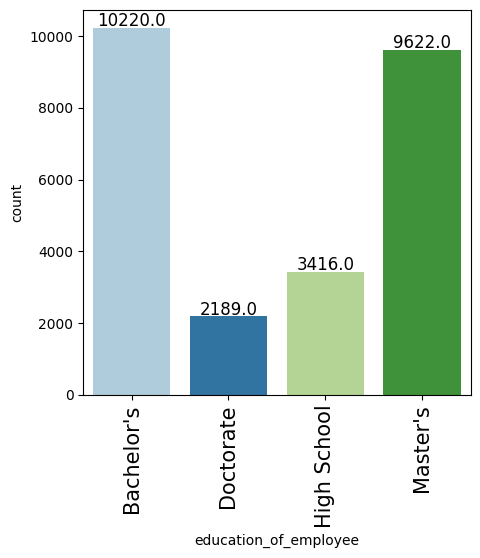

In [34]:
labeled_barplot(data=data, feature='education_of_employee')

#### Observations on region of employment

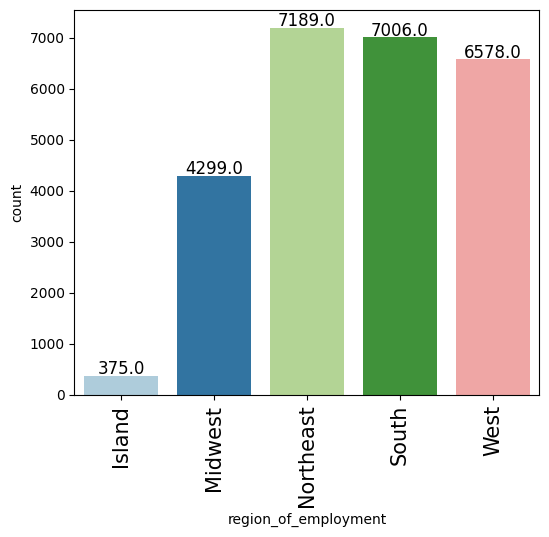

In [35]:
labeled_barplot(data=data, feature='region_of_employment')

#### Observations on job experience

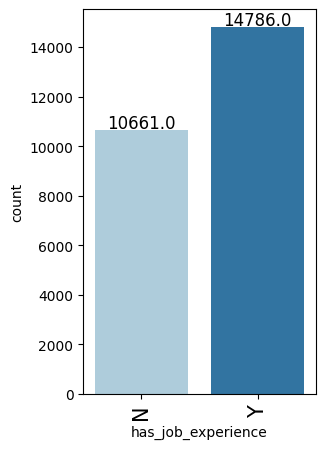

In [36]:
labeled_barplot(data=data, feature='has_job_experience')

#### Observations on case status

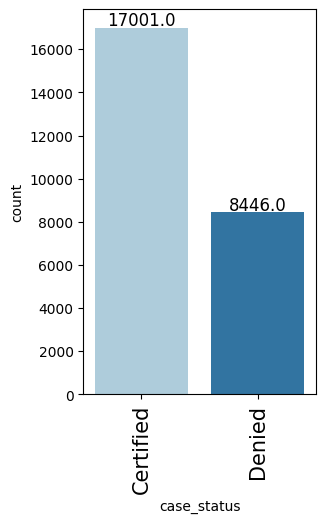

In [37]:
labeled_barplot(data=data, feature='case_status')

### Bivariate Analysis

**Creating functions that will help us with further analysis.**

In [38]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [39]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

#### Does higher education increase the chances of visa certification for well-paid jobs abroad?

case_status            Certified  Denied    All
education_of_employee                          
All                        17001    8446  25447
Bachelor's                  6362    3858  10220
High School                 1164    2252   3416
Master's                    7565    2057   9622
Doctorate                   1910     279   2189
------------------------------------------------------------------------------------------------------------------------


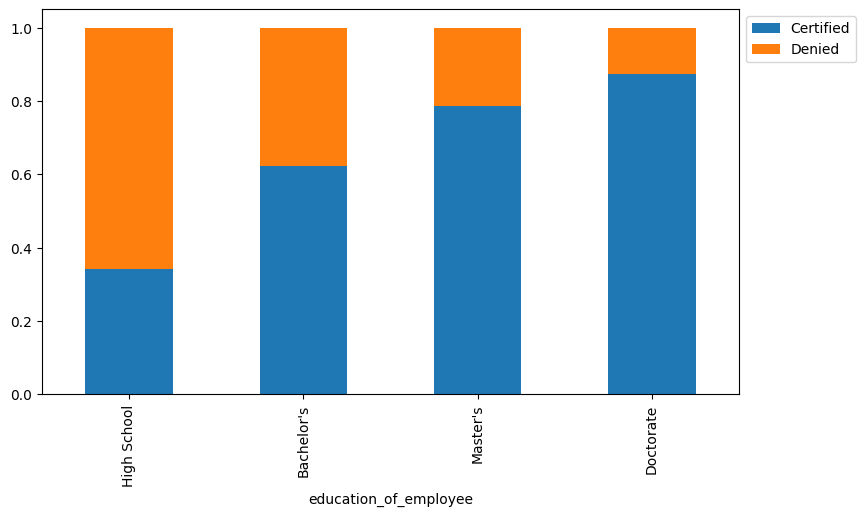

In [40]:
stacked_barplot(data=data, predictor='education_of_employee', target='case_status')

Observation: Higher education does increase the chances of visa certification.

#### How does visa status vary across different continents?

case_status    Certified  Denied    All
continent                              
All                17001    8446  25447
Asia               11001    5839  16840
North America       2037    1250   3287
Europe              2953     774   3727
South America        492     359    851
Africa               396     154    550
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


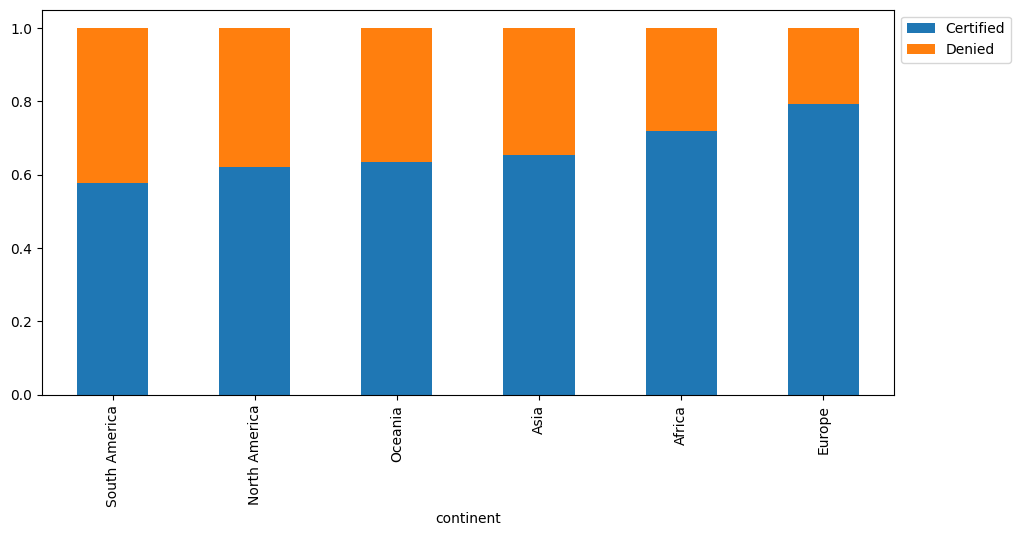

In [41]:
stacked_barplot(data=data, predictor='continent', target='case_status')

Observation: Visa status is more likely to be confirmed if the employee is from Europe or Africa compared to Americas.

#### Does having prior work experience influence the chances of visa certification for career opportunities abroad?

case_status         Certified  Denied    All
has_job_experience                          
All                     17001    8446  25447
N                        5986    4675  10661
Y                       11015    3771  14786
------------------------------------------------------------------------------------------------------------------------


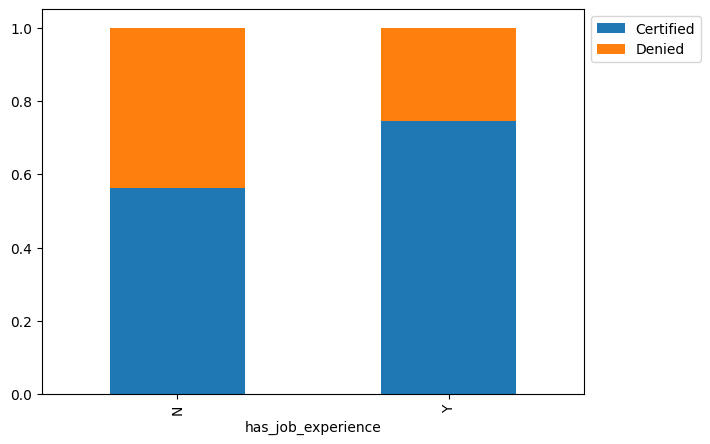

In [42]:
stacked_barplot(data=data, predictor='has_job_experience', target='case_status')

Observation: Having prior work eperience helps in getting visa certified.

#### Is the prevailing wage consistent across all regions of the US?

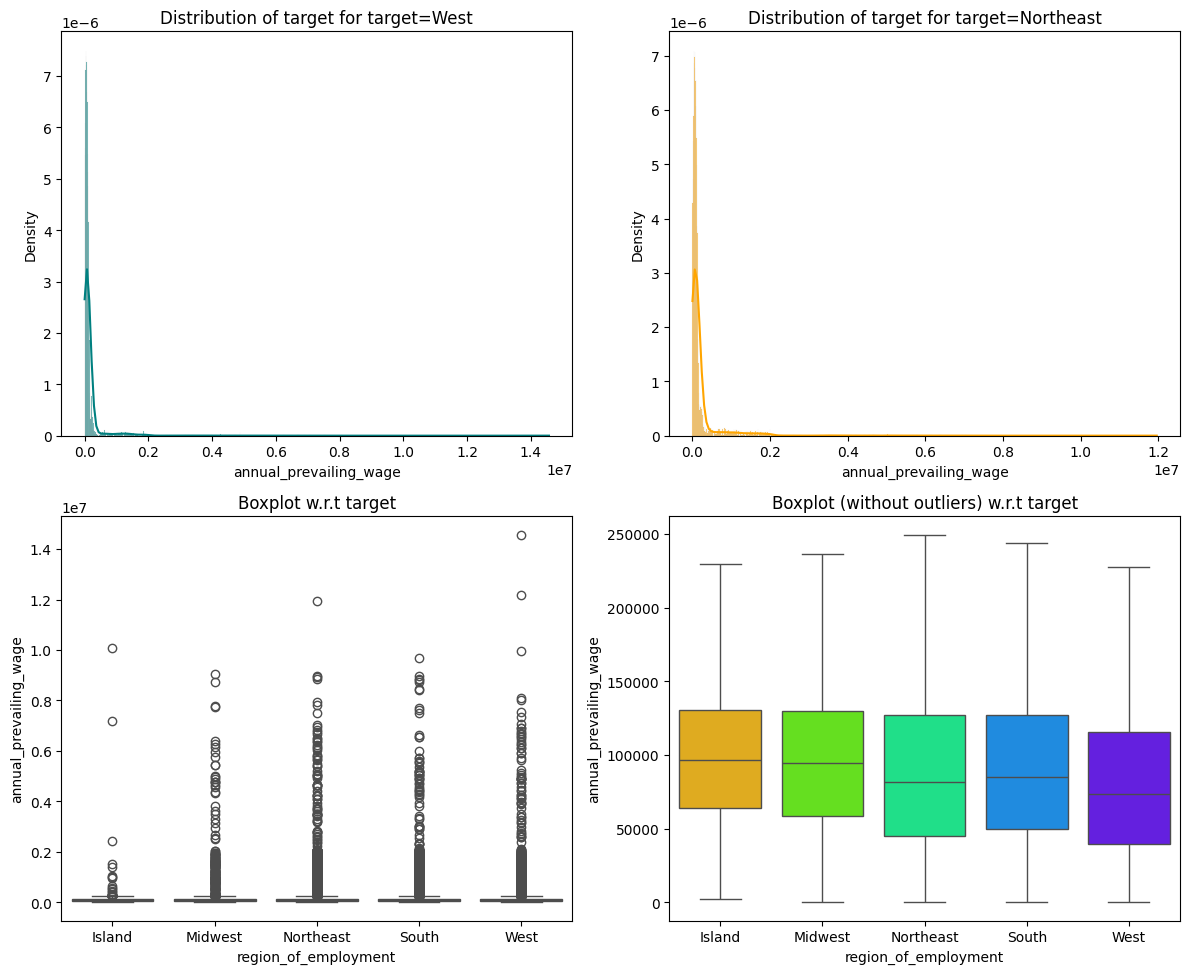

In [43]:
distribution_plot_wrt_target(data=data, predictor='annual_prevailing_wage', target='region_of_employment')

In [44]:
data.groupby('region_of_employment')['annual_prevailing_wage'].mean()

,annual_prevailing_wage
region_of_employment,
Island,170732.100005
Midwest,159477.898051
Northeast,224692.872481
South,209094.858907
West,181665.233538


Obervation: The prevailing wage is fairly consistent across all regions. If you exclude outliers 'West' has a lower wage than others but if you include them it is about the same as the US average. That implies ore outliers in West and similarly in Northeast.

#### Does visa status vary with changes in the prevailing wage set to protect both local talent and foreign workers?

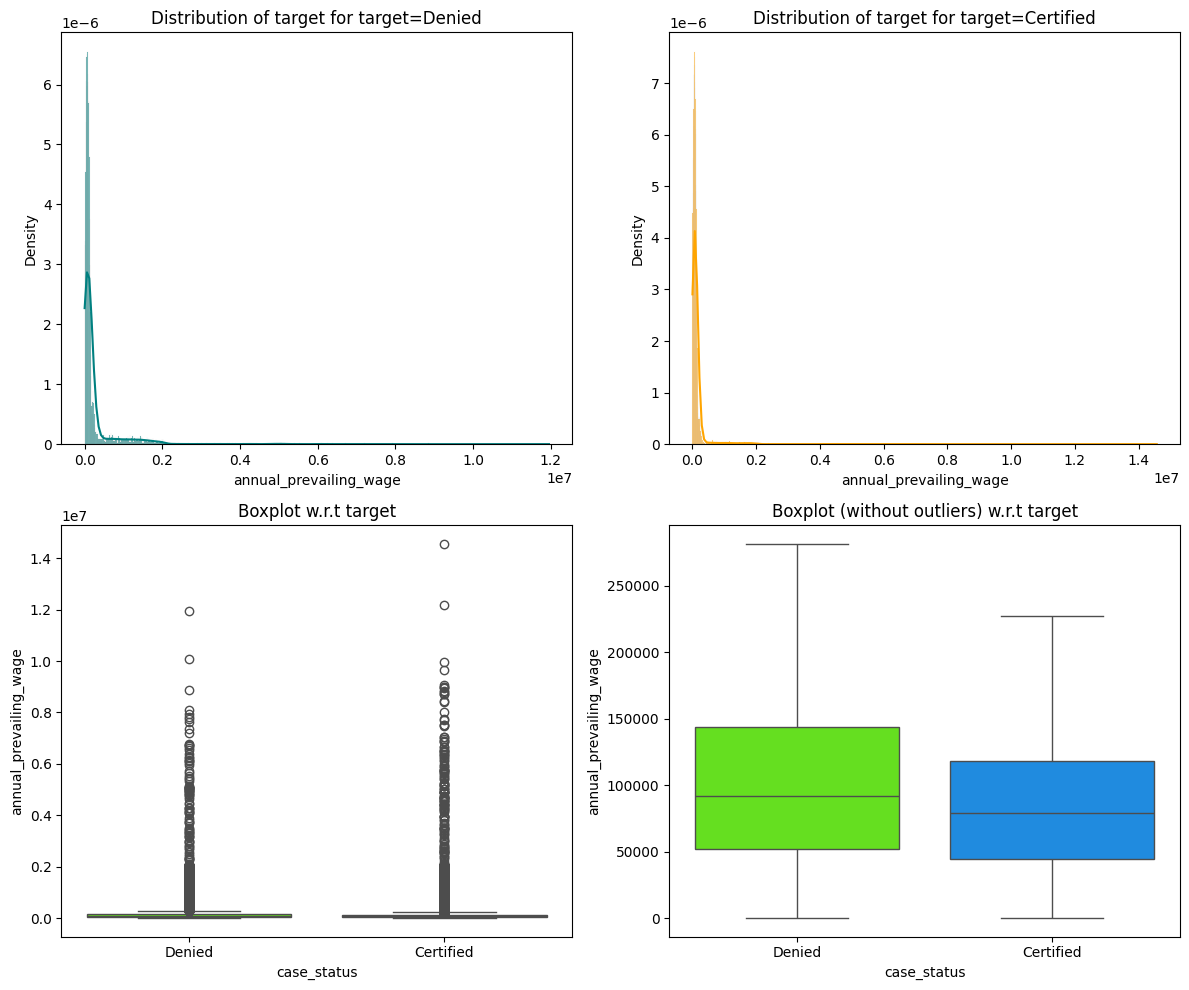

In [45]:
distribution_plot_wrt_target(data=data, predictor='annual_prevailing_wage', target='case_status')

<Axes: xlabel='prevailing_wage', ylabel='Count'>

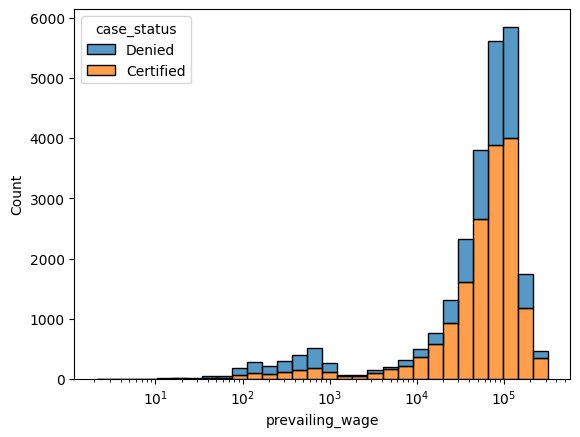

In [46]:
sns.histplot(data=data, x='prevailing_wage', hue='case_status', log_scale=True, multiple = 'stack', bins=30)

At first glance the prevailing wage seems to improve the case_status. But this observation is not seen it the annual prevailing wage which is rather surprising.

<Axes: xlabel='annual_prevailing_wage', ylabel='Count'>

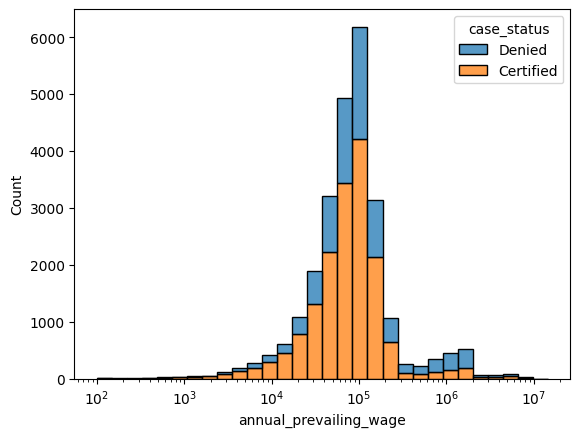

In [47]:
sns.histplot(data=data, x='annual_prevailing_wage', hue='case_status', log_scale=True, multiple = 'stack', bins=30)

#### Does the unit of prevailing wage (Hourly, Weekly, etc.) have any impact on the likelihood of visa application certification?

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


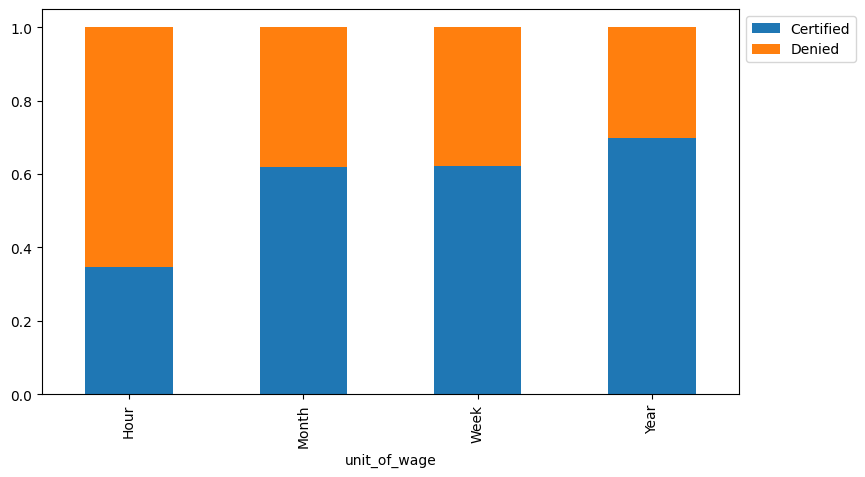

In [48]:
stacked_barplot(data=df, predictor='unit_of_wage', target='case_status')

Another surprising observation that the unit of wage matters significantly on whether the case was approved or denied. Perhaps occupations which are more restricted tend to have prevailing wage reported on hourly basis.

## Data Pre-processing

### Outlier Check

In [49]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25447.0,5674.415334,22891.842245,12.0000,1025.000,2112.0,3506.500,602069.00
yr_of_estab,25447.0,1979.394506,42.385932,1800.0000,1976.000,1997.0,2005.000,2016.00
prevailing_wage,25447.0,74468.281479,52822.177370,2.1367,34039.210,70312.5,107739.505,319210.27
annual_prevailing_wage,25447.0,197463.338280,578893.001653,100.0000,47137.505,82838.4,124826.630,14569149.40


In [50]:
data[data['annual_prevailing_wage']>1000000].count()

,0
continent,1155
education_of_employee,1155
has_job_experience,1155
requires_job_training,1155
no_of_employees,1155
yr_of_estab,1155
region_of_employment,1155
prevailing_wage,1155
unit_of_wage,1155
full_time_position,1155


In [51]:
data[data['annual_prevailing_wage']>1000000].head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,annual_prevailing_wage
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,1231782.032
78,North America,Master's,N,N,1549,2001,South,590.0203,Hour,Y,Certified,1227242.224
92,Asia,Bachelor's,N,N,3667,1970,Northeast,527.8901,Hour,Y,Denied,1098011.408
113,North America,High School,Y,N,1019,2005,South,98966.7200,Week,Y,Certified,5146269.440
116,Asia,Bachelor's,Y,N,509,1997,South,32400.2000,Week,Y,Certified,1684810.400


In [52]:
data[data['annual_prevailing_wage']>1000000].tail()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,annual_prevailing_wage
25432,Asia,Bachelor's,Y,N,1236,2008,West,154057.6400,Week,Y,Certified,8010997.280
25434,North America,Bachelor's,N,N,2347,1998,Northeast,891.2318,Hour,Y,Denied,1853762.144
25450,Asia,Bachelor's,N,N,3312,2009,Northeast,682.1048,Hour,Y,Denied,1418777.984
25465,North America,High School,N,N,2577,1995,South,481.2238,Hour,Y,Certified,1000945.504
25470,North America,Master's,Y,N,2272,1970,Northeast,516.4101,Hour,Y,Certified,1074133.008


It looks like the unit_of_wage may have been mislabeled in some cases. Therefore the distribution of annual_prevailing_wage is bimodal. To handle those outliers we might need to exclude all employees with wages above 5,000,000. But we might ahve to look in closer as to why the distribution is bimodal.

<Axes: xlabel='prevailing_wage', ylabel='Count'>

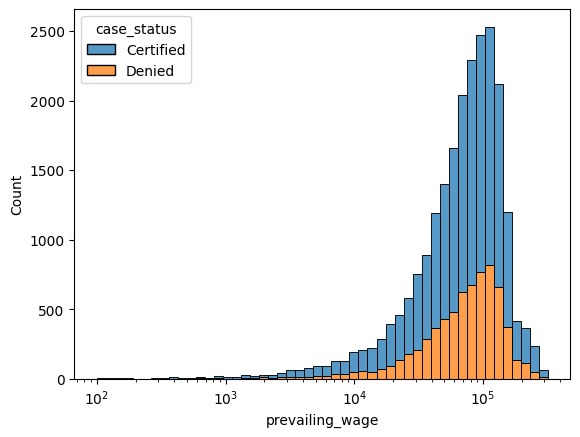

In [53]:
sns.histplot(data=data[data['unit_of_wage']=='Year'], x='prevailing_wage', hue='case_status', log_scale=True, multiple = 'stack', bins=50)

<Axes: xlabel='prevailing_wage', ylabel='Count'>

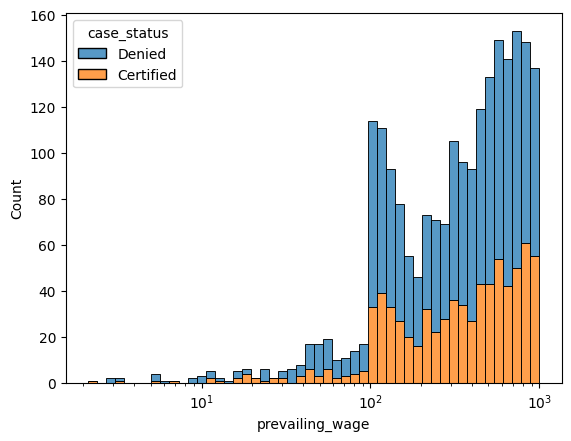

In [54]:
sns.histplot(data=data[data['unit_of_wage']=='Hour'], x='prevailing_wage', hue='case_status', log_scale=True, multiple = 'stack', bins=50)

On breaking down the distribution, it looks like the distribution for Unit of wage being 'Year' has no issues but the rows with unit of wage 'Hour'  looks odd since most rows have values close to $1000 and then it abruptly stops there. We would expect a right skewness as opposed to a left skewness.

Perhaps the hourly wages have an extra 0 and therefore they are 10 times what would be expected.

In [55]:
data.drop('prevailing_wage', axis=1, inplace=True)

Removing Prevailing wage for the analysis.

### Data Preparation for modeling

In [56]:
# separating the independent and dependent variables
X = data.drop(["case_status"], axis=1)
y = data["case_status"].apply(lambda x: 1 if x == "Denied" else 0)
# True cases are those who are denied



In [57]:
y.head()

,case_status
0,1
1,0
2,1
3,1
4,0


In [58]:
# creating dummy variables
X = pd.get_dummies(X, drop_first=True)

In [59]:
# Splitting data into training, validation and test set:

# first we split data into 2 parts, say temporary and test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# then we split the temporary set into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

print(X_train.shape, X_val.shape, X_test.shape)

(16285, 21) (4072, 21) (5090, 21)


## Model Building

### Model Evaluation Criterion

- Choose the primary metric to evaluate the model on
- Elaborate on the rationale behind choosing the metric

First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.
* The `model_performance_classification_sklearn` function will be used to check the model performance of models.
* The `confusion_matrix_sklearn` function will be used to plot the confusion matrix.

In [60]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [61]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

#### Defining scorer to be used for cross-validation and hyperparameter tuning

In [62]:
y.sum()

np.int64(8446)

In the given scenario a false negative will lead to an approval for an employee who should have been otherwise rejected. This will disadvantage local talent. A false positive will end up denying a employee who should have been approved. In this case the company will not have the right personnel for their operations since local talent is unavailable in this scenario.

I believe both cases are equaly undesirable. Also, the number of cases with 'Denied' are of the same order of magnitude as those which are 'Certified' so the problem isn't too imbalanced. This suggests that F1 score is the best metric for model evaluation.

**We are now done with pre-processing and evaluation criterion, so let's start building the model.**

### Model building with Original data

In [71]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\nTraining Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = f1_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))

print("\nValidation Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores_val = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.9648489454683641
Random forest: 0.9999074845036544
GBM: 0.58377239199157
Adaboost: 0.5400871459694989
dtree: 1.0

Validation Performance:

Bagging: 0.4997849462365591
Random forest: 0.5290215588723052
GBM: 0.5666527371500208
Adaboost: 0.5464764375270211
dtree: 0.46848190973517345


In [72]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_train = f1_score(y_train, model.predict(X_train))
    scores_val = f1_score(y_val, model.predict(X_val))
    difference1 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference1))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9648, Validation Score: 0.4998, Difference: 0.4651
Random forest: Training Score: 0.9999, Validation Score: 0.5290, Difference: 0.4709
GBM: Training Score: 0.5838, Validation Score: 0.5667, Difference: 0.0171
Adaboost: Training Score: 0.5401, Validation Score: 0.5465, Difference: -0.0064
dtree: Training Score: 1.0000, Validation Score: 0.4685, Difference: 0.5315


Observation:
 1) There is a big difference between the training and validation F1 scores for Bagging, Random Forest and Decision Trees. These models tend to overfit and therefore it is expected that their score on the training data will be close to perfect.
 2) Adaboost and GBM perform much better in the validation data and at the same time, they aren't overfit since their performance is comparable between the training data and validation data.

### Model Building with Oversampled data

In [73]:
print("Before Oversampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label '0': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label '1': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label '0': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label '1': 5405
Before Oversampling, counts of label '0': 10880 

After Oversampling, counts of label '1': 10880
After Oversampling, counts of label '0': 10880 

After Oversampling, the shape of train_X: (21760, 21)
After Oversampling, the shape of train_y: (21760,) 



In [74]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = f1_score(y_train_over, model.predict(X_train_over))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9837742340415639
Random forest: 1.0
GBM: 0.7817948970544774
Adaboost: 0.7489724619810934
dtree: 1.0

Validation Performance:

Bagging: 0.5100451004510045
Random forest: 0.5435897435897435
GBM: 0.5803571428571429
Adaboost: 0.5403295750216826
dtree: 0.4833512352309345


In [75]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_train = recall_score(y_train_over, model.predict(X_train_over))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference2 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference2))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9724, Validation Score: 0.4601, Difference: 0.5124
Random forest: Training Score: 1.0000, Validation Score: 0.5096, Difference: 0.4904
GBM: Training Score: 0.7294, Validation Score: 0.5288, Difference: 0.2006
Adaboost: Training Score: 0.6699, Validation Score: 0.4608, Difference: 0.2091
dtree: Training Score: 1.0000, Validation Score: 0.4993, Difference: 0.5007


Observations:
1) There is a marginal improvement in the validation data performance for all models except Adaboost.
2) The difference between performance in training and validation set has increased and that can be attributed to the fact that we oversampled the training set but not the validation set.

### Model Building with Undersampled data

In [76]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [77]:
print("Before Under Sampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Yes': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'No': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Yes': 5405
Before Under Sampling, counts of label 'No': 10880 

After Under Sampling, counts of label 'Yes': 5405
After Under Sampling, counts of label 'No': 5405 

After Under Sampling, the shape of train_X: (10810, 21)
After Under Sampling, the shape of train_y: (10810,) 



In [78]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))


print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_train_un, model.predict(X_train_un))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9757631822386679
Random forest: 1.0
GBM: 0.6999074930619796
Adaboost: 0.6723404255319149
dtree: 1.0

Validation Performance:

Bagging: 0.6190828402366864
Random forest: 0.6708579881656804
GBM: 0.6989644970414202
Adaboost: 0.6812130177514792
dtree: 0.6346153846153846


In [79]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores_train = recall_score(y_train_un, model.predict(X_train_un))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference3 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference3))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9758, Validation Score: 0.6191, Difference: 0.3567
Random forest: Training Score: 1.0000, Validation Score: 0.6709, Difference: 0.3291
GBM: Training Score: 0.6999, Validation Score: 0.6990, Difference: 0.0009
Adaboost: Training Score: 0.6723, Validation Score: 0.6812, Difference: -0.0089
dtree: Training Score: 1.0000, Validation Score: 0.6346, Difference: 0.3654


Observations:
1) The performance of all models have improved significantly with the undersampling.
2) GBM is the best model with an F1 score of nearly 0.7 on the Validation set.

## Hyperparameter Tuning

**Best practices for hyperparameter tuning in AdaBoost:**

`n_estimators`:

- Start with a specific number (50 is used in general) and increase in steps: 50, 75, 85, 100

- Use fewer estimators (e.g., 50 to 100) if using complex base learners (like deeper decision trees)

- Use more estimators (e.g., 100 to 150) when learning rate is low (e.g., 0.1 or lower)

- Avoid very high values unless performance keeps improving on validation

`learning_rate`:

- Common values to try: 1.0, 0.5, 0.1, 0.01

- Use 1.0 for faster training, suitable for fewer estimators

- Use 0.1 or 0.01 when using more estimators to improve generalization

- Avoid very small values (< 0.01) unless you plan to use many estimators (e.g., >500) and have sufficient data


---

**Best practices for hyperparameter tuning in Random Forest:**


`n_estimators`:

* Start with a specific number (50 is used in general) and increase in steps: 50, 75, 100, 125
* Higher values generally improve performance but increase training time
* Use 100-150 for large datasets or when variance is high


`min_samples_leaf`:

* Try values like: 1, 2, 4, 5, 10
* Higher values reduce model complexity and help prevent overfitting
* Use 1–2 for low-bias models, higher (like 5 or 10) for more regularized models
* Works well in noisy datasets to smooth predictions


`max_features`:

* Try values: `"sqrt"` (default for classification), `"log2"`, `None`, or float values (e.g., `0.3`, `0.5`)
* `"sqrt"` balances between diversity and performance for classification tasks
* Lower values (e.g., `0.3`) increase tree diversity, reducing overfitting
* Higher values (closer to `1.0`) may capture more interactions but risk overfitting


`max_samples` (for bootstrap sampling):

* Try float values between `0.5` to `1.0` or fixed integers
* Use `0.6–0.9` to introduce randomness and reduce overfitting
* Smaller values increase diversity between trees, improving generalization

---

**Best practices for hyperparameter tuning in Gradient Boosting:**

`n_estimators`:

* Start with 100 (default) and increase: 100, 200, 300, 500
* Typically, higher values lead to better performance, but they also increase training time
* Use 200–500 for larger datasets or complex problems
* Monitor validation performance to avoid overfitting, as too many estimators can degrade generalization


`learning_rate`:

* Common values to try: 0.1, 0.05, 0.01, 0.005
* Use lower values (e.g., 0.01 or 0.005) if you are using many estimators (e.g., > 200)
* Higher learning rates (e.g., 0.1) can be used with fewer estimators for faster convergence
* Always balance the learning rate with `n_estimators` to prevent overfitting or underfitting


`subsample`:

* Common values: 0.7, 0.8, 0.9, 1.0
* Use a value between `0.7` and `0.9` for improved generalization by introducing randomness
* `1.0` uses the full dataset for each boosting round, potentially leading to overfitting
* Reducing `subsample` can help reduce overfitting, especially in smaller datasets


`max_features`:

* Common values: `"sqrt"`, `"log2"`, or float (e.g., `0.3`, `0.5`)
* `"sqrt"` (default) works well for classification tasks
* Lower values (e.g., `0.3`) help reduce overfitting by limiting the number of features considered at each split

---

**Best practices for hyperparameter tuning in XGBoost:**

`n_estimators`:

* Start with 50 and increase in steps: 50,75,100,125.
* Use more estimators (e.g., 150-250) when using lower learning rates
* Monitor validation performance
* High values improve learning but increase training time

`subsample`:

* Common values: 0.5, 0.7, 0.8, 1.0
* Use `0.7–0.9` to introduce randomness and reduce overfitting
* `1.0` uses the full dataset in each boosting round; may overfit on small datasets
* Values < 0.5 are rarely useful unless dataset is very large

`gamma`:

* Try values: 0 (default), 1, 3, 5, 8
* Controls minimum loss reduction needed for a split
* Higher values make the algorithm more conservative (i.e., fewer splits)
* Use values > 0 to regularize and reduce overfitting, especially on noisy data


`colsample_bytree`:

* Try values: 0.3, 0.5, 0.7, 1.0
* Fraction of features sampled per tree
* Lower values (e.g., 0.3 or 0.5) increase randomness and improve generalization
* Use `1.0` when you want all features considered for every tree


`colsample_bylevel`:

* Try values: 0.3, 0.5, 0.7, 1.0
* Fraction of features sampled at each tree level (i.e., per split depth)
* Lower values help in regularization and reducing overfitting
* Often used in combination with `colsample_bytree` for fine control over feature sampling

---

## Model Performance Summary and Final Model Selection

## Actionable Insights and Recommendations

<font size=6 color='blue'>Power Ahead</font>
___